# Covid

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_covid = pd.read_csv('../Data/gold/covid_multivariate_w_2.csv')
df_covid.head()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated
0,2020-03-23,Chile,1558,10261,5.828571,5.242857,10.619048,28.350649,37.952381,3.773810,19331414,30,8,9,32,19.456667,69.844286,0.0
1,2020-03-30,Chile,2420,24909,5.978571,6.516667,13.771429,38.922078,50.726190,4.035714,19331414,27,7,10,28,12.998571,75.930000,0.0
2,2020-04-06,Chile,2987,43938,6.235714,6.992857,12.733333,43.142857,66.071429,3.840476,19331414,28,7,9,25,11.041429,75.930000,0.0
3,2020-04-13,Chile,3304,65523,7.383333,8.771429,11.707143,43.233766,69.059524,4.076190,19331414,28,6,9,21,10.270000,75.930000,0.0
4,2020-04-20,Chile,4054,90640,6.742857,6.788095,11.769048,38.662338,63.321429,3.661905,19331414,24,6,9,21,10.878571,75.930000,0.0


In [13]:
# create shifted col for new_cases grouped by country
df_covid['new_cases_1'] = df_covid.groupby('country')['new_cases'].shift(-1)
df_covid.dropna(subset=['new_cases_1'], inplace=True)

# Only Colombia

In [14]:
df_col = df_covid[df_covid['country'] == 'Colombia'].copy()
df_col

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated,new_cases_1
145,2020-03-23,Colombia,471,3465,6.007143,7.164286,18.142857,48.857143,118.285714,0.742857,50326931,28,10,6,44,7.531667,78.171429,0.000000,783.0
146,2020-03-30,Colombia,783,8088,5.992857,6.228571,13.057143,25.214286,63.214286,0.628571,50326931,31,8,6,40,4.344286,87.960000,0.000000,1291.0
147,2020-04-06,Colombia,1291,15594,4.335714,4.700000,11.757143,15.214286,37.285714,0.614286,50326931,40,8,6,38,2.705714,87.960000,0.000000,1016.0
148,2020-04-13,Colombia,1016,23021,5.028571,7.000000,12.092857,31.571429,74.785714,0.642857,50326931,27,8,5,31,1.977143,84.788571,0.000000,1587.0
149,2020-04-20,Colombia,1587,32445,5.207143,7.192857,9.607143,23.071429,53.500000,0.442857,50326931,24,7,5,29,2.207143,85.451429,0.000000,2289.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,2022-11-21,Colombia,0,44188599,12.914286,12.471429,3.957143,32.571429,61.928571,0.542857,51443283,22,7,4,24,15.328571,19.440000,70.988571,1450.0
285,2022-11-28,Colombia,1450,44192949,10.078571,11.414286,4.650000,30.500000,58.642857,0.685714,51443283,12,6,5,24,15.254286,19.440000,71.040000,2903.0
286,2022-12-05,Colombia,2903,44213264,6.214286,11.164286,4.492857,32.642857,63.428571,0.514286,51443283,13,11,5,27,15.428571,19.440000,71.040000,5271.0
287,2022-12-12,Colombia,5271,44240154,6.285714,10.728571,4.085714,35.642857,60.857143,0.500000,51443283,12,11,4,25,15.705714,19.440000,71.061429,6708.0


In [15]:
# Convert the date column to datetime format
df_col['date'] = pd.to_datetime(df_col['date'])
# get numeric date
df_col['date_num'] = df_col['date'].map(pd.Timestamp.toordinal)

In [19]:
# get only numeric columns
df_col_num = df_col.select_dtypes(include=[np.number])
# re order columns
df_col_num = df_col_num[['new_cases_1','new_cases', 'cases', 'co', 'no2', 'o3', 'pm10', 'pm25', 'so2',
       'population', 'google_physician', 'google_hospital', 'google_pharmacy',
       'google_symptom', 'Mean_distance_avg_14day_movavg',
       'StringencyIndex_Average', 'pop_vaccinated', 'date_num']]

In [78]:
# train test split - time series
train_size = int(len(df_col_num) * 0.8)
df_train, df_test = df_col_num.iloc[:train_size], df_col_num.iloc[train_size:]


## Correlation

### Autocorrelation

Text(0.5, 1.0, 'PACF – new_cases')

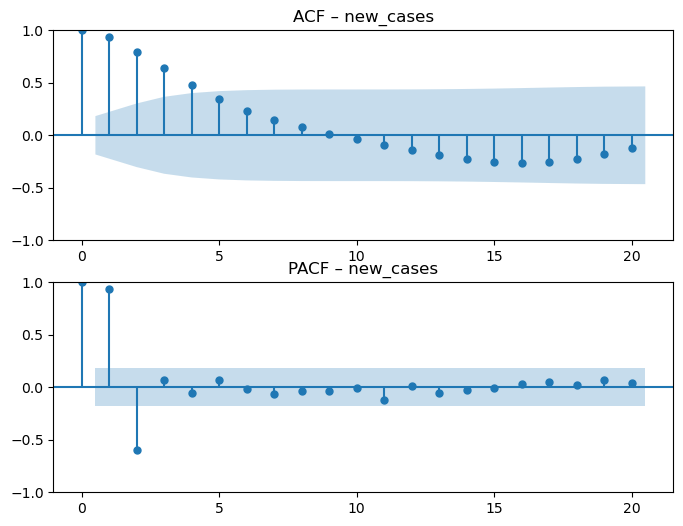

In [80]:
# get ACF and PACF for new_cases
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

series = df_train['new_cases'].dropna()

fig, axes = plt.subplots(2, 1, figsize=(8, 6))

plot_acf(series, lags=20, ax=axes[0])
axes[0].set_title("ACF – new_cases")

plot_pacf(series, lags=20, ax=axes[1], method="ywm")  # Yule‑Walker‑Modified
axes[1].set_title("PACF – new_cases")

There is high autocorrelation of new cases, so lag 1, and 2 could be useful

### Pearson

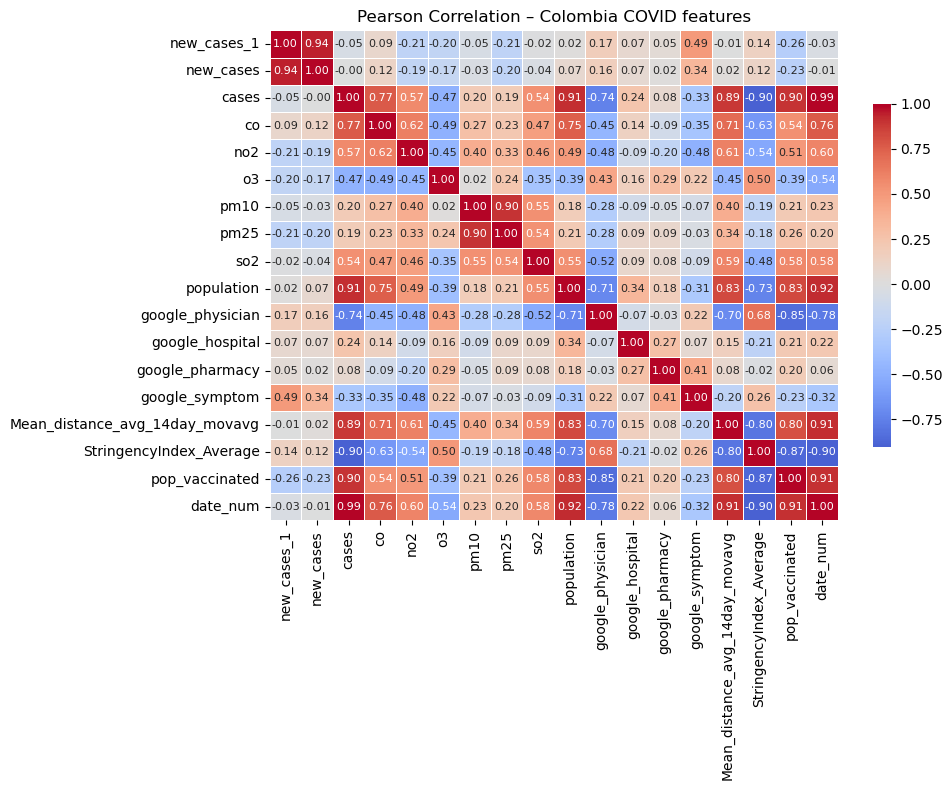

In [81]:

# 2) Pearson correlation
corr = df_train.corr(method="pearson")

# 3) heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr,
            annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            linewidths=.5,
            cbar_kws={"shrink": .7},
            annot_kws={"size": 8})   # ← control annotation font size

plt.title("Pearson Correlation – Colombia COVID features")
plt.tight_layout()
plt.show()

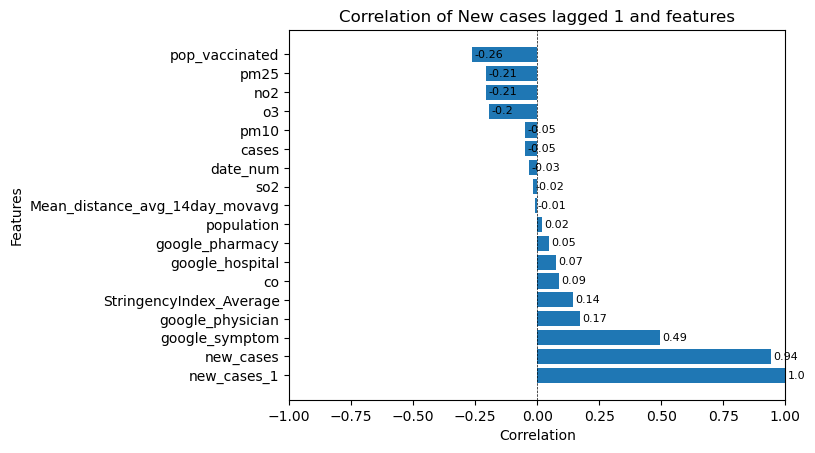

In [82]:
simple_corr = corr[['new_cases_1']].rename(columns = {"new_cases_1":'corralation'})
simple_corr.sort_values(by='corralation', ascending=False, inplace=True)
plt.barh(simple_corr.index, simple_corr['corralation'])
plt.title("Correlation of New cases lagged 1 and features")
# include annotations
for i, v in enumerate(simple_corr['corralation']):
    plt.text(v + 0.01, i, str(round(v, 2)), color='black', va='center', fontsize=8)
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.xlim(-1, 1)
plt.axvline(x=0, color='black', linewidth=0.5, linestyle='--')
plt.show()

### Spearman

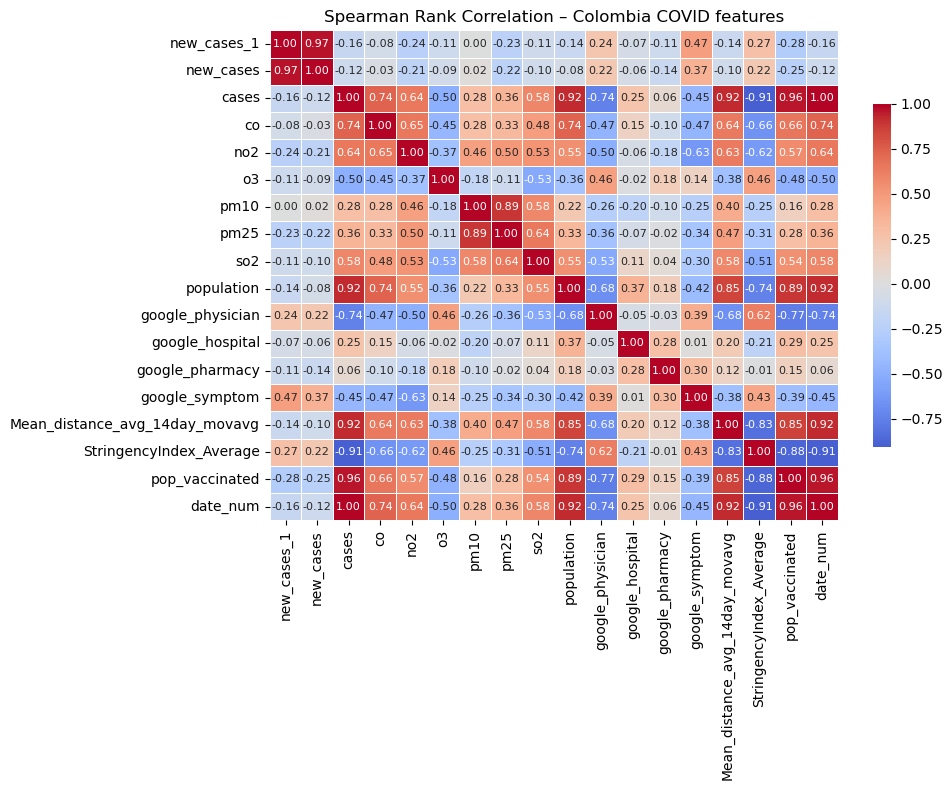

In [83]:

# 2) Pearson correlation
corr_sp = df_train.corr(method="spearman")

# 3) heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_sp,
            annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            linewidths=.5,
            cbar_kws={"shrink": .7},
            annot_kws={"size": 8})   # ← control annotation font size

plt.title("Spearman Rank Correlation – Colombia COVID features")
plt.tight_layout()
plt.show()

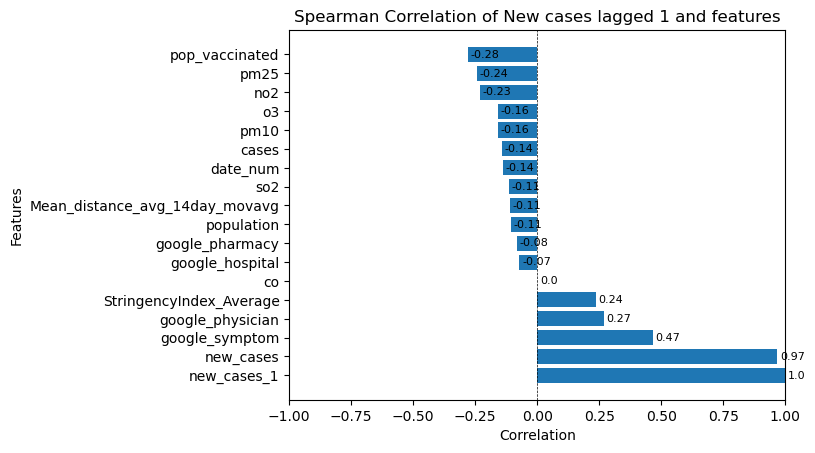

In [84]:
spearman_corr = corr_sp[['new_cases_1']].rename(columns = {"new_cases_1":'corralation'})
spearman_corr.sort_values(by='corralation', ascending=False, inplace=True)
plt.barh(simple_corr.index, spearman_corr['corralation'])
plt.title("Spearman Correlation of New cases lagged 1 and features")
# include annotations
for i, v in enumerate(spearman_corr['corralation']):
    plt.text(v + 0.01, i, str(round(v, 2)), color='black', va='center', fontsize=8)
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.xlim(-1, 1)
plt.axvline(x=0, color='black', linewidth=0.5, linestyle='--')
plt.show()

In [85]:
# change names of simple_corr and spearman_corr
simple_corr.rename(columns = {"corralation":"pearson_corr"}, inplace=True)
spearman_corr.rename(columns = {"corralation":"spearman_corr"}, inplace=True)

In [86]:
# merge spearman_corr and simple_corr by index
df_corr = pd.merge(simple_corr, spearman_corr, left_index=True, right_index=True)
 

In [87]:
df_corr

,pearson_corr,spearman_corr
new_cases_1,1.000000,1.000000
new_cases,0.941844,0.967884
google_symptom,0.493111,0.465149
google_physician,0.172611,0.236605
StringencyIndex_Average,0.142741,0.270038
co,0.088511,-0.081117
google_hospital,0.074085,-0.071692
google_pharmacy,0.045384,-0.112771
population,0.017273,-0.140487
Mean_distance_avg_14day_movavg,-0.009279,-0.136515


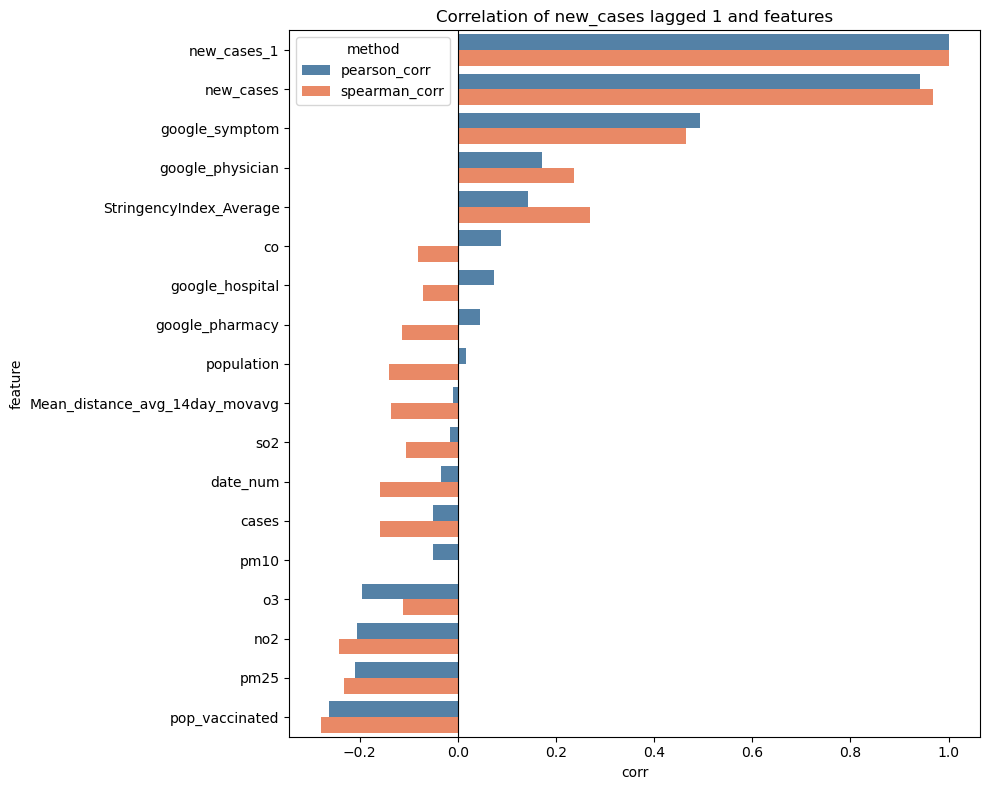

In [88]:
# df_corr has index = feature names and two columns
df_plot = (
    df_corr.reset_index()                       # bring feature names into a column
            .melt(id_vars="index",
                  value_vars=["pearson_corr", "spearman_corr"],
                  var_name="method", value_name="corr")
            .rename(columns={"index": "feature"})
)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=df_plot,
    y="feature", x="corr", hue="method",
    orient="h", dodge=True,  # dodge=True puts the bars side‑by‑side
    palette={"pearson_corr": "steelblue", "spearman_corr": "coral"}
)
plt.axvline(0, color="k", linewidth=.8)
plt.title("Correlation of new_cases lagged 1 and features")
plt.tight_layout()
plt.show()


Both correlations are similar in magnitude, there are no substantial changes in which variables are correlated except for ```co``` and overall the negtively correlated variables are more correlated via Spearman Rank, than via Pearsons

In [89]:
# get the top 10 features by absolute value of spearman correlation
df_corr['spearman_corr_abs'] = df_corr['spearman_corr'].abs()
df_corr.sort_values(by='spearman_corr_abs', ascending=False, inplace=True)
df_corr_top10 = df_corr.head(10).copy()
df_corr_top10.reset_index(inplace=True)
df_corr_top10.rename(columns = {"index":"feature"}, inplace=True)
df_corr_top10

,feature,pearson_corr,spearman_corr,spearman_corr_abs
0,new_cases_1,1.000000,1.000000,1.000000
1,new_cases,0.941844,0.967884,0.967884
2,google_symptom,0.493111,0.465149,0.465149
3,pop_vaccinated,-0.263033,-0.279314,0.279314
4,StringencyIndex_Average,0.142741,0.270038,0.270038
5,no2,-0.205928,-0.241519,0.241519
6,google_physician,0.172611,0.236605,0.236605
7,pm25,-0.208724,-0.232206,0.232206
8,date_num,-0.034257,-0.158494,0.158494
9,cases,-0.049965,-0.158494,0.158494


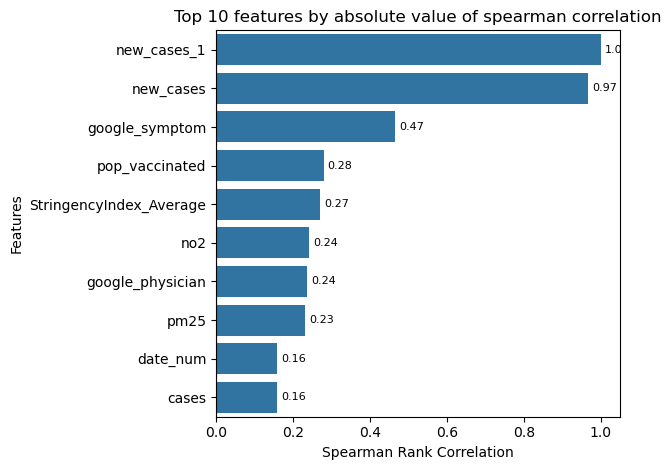

In [90]:
# plot barh of top 10 features by absolute value of spearman correlation
sns.barplot(
    data=df_corr_top10,
    y="feature", x="spearman_corr_abs",
    orient="h", dodge=True,  # dodge=True puts the bars side‑by‑side
)
# add annotations
for i, v in enumerate(df_corr_top10['spearman_corr_abs']):
    plt.text(v + 0.01, i, str(round(v, 2)), color='black', va='center', fontsize=8)
plt.axvline(0, color="k", linewidth=.8)
plt.title("Top 10 features by absolute value of spearman correlation")
plt.xlabel("Spearman Rank Correlation")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

### ANOVA

In [97]:
from sklearn.feature_selection import f_regression


# ----- run the F‑test -----
X = df_train.drop(columns=['new_cases_1'])
y = df_train['new_cases_1']

F, p = f_regression(X, y)          # F‑scores and two‑sided p‑values

# ----- wrap in a tidy table -----
feat_scores = (
    pd.DataFrame({"feature": X.columns,
                  "F_score": F,
                  "p_value": p})
      .sort_values("F_score", ascending=False)
      .reset_index(drop=True)
)

print(feat_scores.head(10))        # top‑10 features

# List of “selected” features, choose a rule:
alpha = 0.1                       # keep features with p < 0.05
selected = feat_scores.loc[feat_scores["p_value"] < alpha, "feature"].tolist()

print("\nSelected features (p < 0.05):")
print(selected)


                   feature     F_score       p_value
0                new_cases  887.614429  2.420147e-55
1           google_symptom   36.304776  2.158751e-08
2           pop_vaccinated    8.399150  4.510108e-03
3                     pm25    5.147156  2.518337e-02
4                      no2    5.004120  2.724932e-02
5                       o3    4.504981  3.597985e-02
6         google_physician    3.470192  6.508104e-02
7  StringencyIndex_Average    2.350271  1.280562e-01
8                       co    0.892257  3.468816e-01
9          google_hospital    0.623631  4.313551e-01

Selected features (p < 0.05):
['new_cases', 'google_symptom', 'pop_vaccinated', 'pm25', 'no2', 'o3', 'google_physician']


### VIF

In [98]:
df_filtered = df_train[selected].copy()
df_filtered.head()

,new_cases,google_symptom,pop_vaccinated,pm25,no2,o3,google_physician
145,471,44,0.0,118.285714,7.164286,18.142857,28
146,783,40,0.0,63.214286,6.228571,13.057143,31
147,1291,38,0.0,37.285714,4.700000,11.757143,40
148,1016,31,0.0,74.785714,7.000000,12.092857,27
149,1587,29,0.0,53.500000,7.192857,9.607143,24


In [99]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(df_num):
    """df_num: DataFrame with numeric predictors (already scaled/imputed)."""
    X = sm.add_constant(df_num.values)          # add intercept
    vif = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    return pd.Series(vif[1:], index=df_num.columns)  # skip intercept

# after your ANOVA filter:
X_candidates = df_filtered  # numeric only
vif = compute_vif(X_candidates)

high_vif = vif[vif > 5]     # or >10
print("Collinear features:\n", high_vif)

Collinear features:
 Series([], dtype: float64)


In [100]:
vif

new_cases           1.335428
google_symptom      1.478419
pop_vaccinated      3.793735
pm25                1.618825
no2                 2.243984
o3                  2.054924
google_physician    3.842298
dtype: float64

In [101]:
X_candidates.columns

Index(['new_cases', 'google_symptom', 'pop_vaccinated', 'pm25', 'no2', 'o3',
       'google_physician'],
      dtype='object')

Don't drop anything because there is no high VIF

## Wrapper Methods

In [102]:
import statsmodels.api as sm

def stepwise_aic(data: pd.DataFrame,
                 target: str,
                 direction: str = "backward",
                 verbose: bool = True):
    """
    data:      dataframe with all numeric columns
    target:    name of response variable
    direction: "backward", "forward", or "stepwise"
    """
    assert direction in {"backward", "forward", "stepwise"}
    
    y = data[target]
    candidates = list(data.columns.drop(target))
    
    # ----- initial model -----
    if direction == "backward":
        best_set = candidates.copy()
    else:                                  # forward or stepwise
        best_set = []                      # start with intercept only
    
    def fit_aic(features):
        if features:
            X = sm.add_constant(data[features])
        else:
            X = sm.add_constant(pd.DataFrame(index=data.index))  # intercept only
        model = sm.OLS(y, X).fit()
        return model.aic, model
    
    best_aic, best_model = fit_aic(best_set)
    improved = True
    
    if verbose:
        print(f"Start AIC = {best_aic:.3f}  with features = {best_set}")
    
    while improved:
        improved = False
        
        # ----- try removing each feature (if any) -----
        if best_set:
            aics_remove = []
            for f in best_set:
                trial_set = [x for x in best_set if x != f]
                aic, _ = fit_aic(trial_set)
                aics_remove.append((aic, f, trial_set))
            best_remove = min(aics_remove)  # lower AIC is better
        else:
            best_remove = (np.inf, None, best_set)
        
        # ----- try adding each remaining feature -----
        remaining = [f for f in candidates if f not in best_set]
        if remaining:
            aics_add = []
            for f in remaining:
                trial_set = best_set + [f]
                aic, _ = fit_aic(trial_set)
                aics_add.append((aic, f, trial_set))
            best_add = min(aics_add)
        else:
            best_add = (np.inf, None, best_set)
        
        # -------------------------------------------------
        # choose best action depending on direction
        # -------------------------------------------------
        choices = []
        if direction in {"backward", "stepwise"}:
            choices.append(best_remove)
        if direction in {"forward", "stepwise"}:
            choices.append(best_add)
        
        best_choice = min(choices, key=lambda x: x[0])
        candidate_aic, changed_feat, candidate_set = best_choice
        
        if candidate_aic + 1e-4 < best_aic:        # tiny tolerance
            if verbose:
                action = "ADD" if changed_feat in remaining else "DROP"
                print(f"{action:4s} {changed_feat:>25s} -> AIC {candidate_aic:.3f}")
            best_aic, best_set = candidate_aic, candidate_set
            best_model = fit_aic(best_set)[1]
            improved = True
    
    if verbose:
        print("\nFinal model AIC =", best_aic)
        print("Selected features:", best_set if best_set else "[intercept only]")
    return best_model, best_set


### Backward AIC

In [105]:
df_filtered['new_cases_1'] = df_train['new_cases_1'].astype(float)

In [106]:
df_num = df_filtered.copy()   # your dataframe with only numeric columns
target = "new_cases_1"

# 1. backward elimination
back_model, back_feats = stepwise_aic(df_num, target, direction="backward")

Start AIC = 2529.252  with features = ['new_cases', 'google_symptom', 'pop_vaccinated', 'pm25', 'no2', 'o3', 'google_physician']
DROP                      pm25 -> AIC 2527.458
DROP          google_physician -> AIC 2526.451

Final model AIC = 2526.4512733721463
Selected features: ['new_cases', 'google_symptom', 'pop_vaccinated', 'no2', 'o3']


### Forward AIC

In [107]:
# 2. forward selection
fwd_model,  fwd_feats  = stepwise_aic(df_num, target, direction="forward")

Start AIC = 2834.592  with features = []
ADD                  new_cases -> AIC 2585.780
ADD             google_symptom -> AIC 2544.815
ADD                         o3 -> AIC 2532.877
ADD             pop_vaccinated -> AIC 2529.345
ADD                        no2 -> AIC 2526.451

Final model AIC = 2526.4512733721463
Selected features: ['new_cases', 'google_symptom', 'o3', 'pop_vaccinated', 'no2']


### ADD-DEL

In [108]:
# 3. classic stepwise (both directions each step)
step_model, step_feats = stepwise_aic(df_num, target, direction="stepwise")

Start AIC = 2834.592  with features = []
ADD                  new_cases -> AIC 2585.780
ADD             google_symptom -> AIC 2544.815
ADD                         o3 -> AIC 2532.877
ADD             pop_vaccinated -> AIC 2529.345
ADD                        no2 -> AIC 2526.451

Final model AIC = 2526.4512733721463
Selected features: ['new_cases', 'google_symptom', 'o3', 'pop_vaccinated', 'no2']


## Embedded Methods

### Lasso

In [110]:
from sklearn.linear_model import LassoCV, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# 1.  Split features / target
# --------------------------------------------------
y = df_train["new_cases_1"].values
X = df_train.drop(columns=["new_cases_1"]).values
feature_names = df_train.drop(columns=["new_cases_1"]).columns

# --------------------------------------------------
# 2.  Pipeline: scale → LassoCV
#    cv=10 by default, you can pass cv=5, etc.
#    alphas=None lets sklearn build a log‑spaced grid
# --------------------------------------------------
lasso_cv_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("lasso_cv", LassoCV(cv=5, n_jobs=-1, random_state=42))
])

lasso_cv_pipe.fit(X, y)

best_alpha = lasso_cv_pipe.named_steps["lasso_cv"].alpha_
print("Optimal lambda (alpha):", best_alpha)

Optimal lambda (alpha): 2910.1998247770994


In [111]:
# --------------------------------------------------
# 3.  Re‑fit a plain Lasso with that alpha
#    (not strictly necessary—LassoCV refit=True already does it,
#     but this makes the coef_ access cleaner)
# --------------------------------------------------
lasso = Pipeline([
    ("scale", StandardScaler()),
    ("lasso", Lasso(alpha=best_alpha))
])
lasso.fit(X, y)

coefs = lasso.named_steps["lasso"].coef_

# --------------------------------------------------
# 4.  Inspect kept / dropped features
# --------------------------------------------------
coef_table = (
    pd.DataFrame({"feature": feature_names, "coef": coefs})
      .sort_values("coef", key=np.abs, ascending=False)
)

kept     = coef_table[coef_table["coef"] != 0]
dropped  = coef_table[coef_table["coef"] == 0]

print("\n=== Non‑zero coefficients ===")
print(kept)

print("\n=== Dropped (coef = 0) ===")
print(dropped["feature"].tolist())


=== Non‑zero coefficients ===
           feature          coef
0        new_cases  44510.896744
12  google_symptom   9201.700928
4               o3  -2003.570169

=== Dropped (coef = 0) ===
['google_physician', 'pop_vaccinated', 'StringencyIndex_Average', 'Mean_distance_avg_14day_movavg', 'google_pharmacy', 'google_hospital', 'population', 'cases', 'so2', 'pm25', 'pm10', 'no2', 'co', 'date_num']


#### Adaptive Lasso

In [112]:
from sklearn.linear_model  import RidgeCV
from sklearn.metrics       import mean_squared_error, r2_score

# --------------------------------------------------
# 0.  Data split
# --------------------------------------------------
y = df_train["new_cases_1"].values
X = df_train.drop(columns=["new_cases_1"]).values
feature_names = df_train.drop(columns=["new_cases_1"]).columns

# --------------------------------------------------
# 1.  Initial estimator (RidgeCV)
# --------------------------------------------------
ridge_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5))
])
ridge_pipe.fit(X, y)
beta0 = ridge_pipe.named_steps["ridge"].coef_      # in *scaled* space
scale_ = ridge_pipe.named_steps["scale"].scale_    # std‑dev of each column
beta0_unscaled = beta0 / scale_                    # transform back to original units

# --------------------------------------------------
# 2.  Compute adaptive weights
# --------------------------------------------------
gamma = 1.0
eps = 1e-4
weights = 1.0 / (np.abs(beta0_unscaled) + eps)**gamma

# --------------------------------------------------
# 3.  Build weighted matrix  X* = X / weights
#     (equiv. to penalising each coef by λ·w_j)
# --------------------------------------------------
X_weighted = X / weights

# --------------------------------------------------
# 4.  LassoCV on weighted matrix
# --------------------------------------------------
lasso_cv = LassoCV(cv=5, n_jobs=-1, random_state=42)
lasso_cv.fit(X_weighted, y)

best_alpha = lasso_cv.alpha_
print("Adaptive‑lasso optimal λ:", best_alpha)



Adaptive‑lasso optimal λ: 15744914.704650974


In [113]:
# --------------------------------------------------
# 5.  Re‑fit plain Lasso at that λ  (optional)
# --------------------------------------------------
lasso_final = Lasso(alpha=best_alpha)
lasso_final.fit(X_weighted, y)

# back‑transform coefficients:  β̂_adaptive = β̂*/weights
coef_adaptive = lasso_final.coef_ / weights

# --------------------------------------------------
# 6.  Inspect results
# --------------------------------------------------
coef_tbl = (
    pd.DataFrame({"feature": feature_names,
                  "coef": coef_adaptive})
      .sort_values("coef", key=np.abs, ascending=False)
      .reset_index(drop=True)
)

kept    = coef_tbl[coef_tbl["coef"] != 0]
dropped = coef_tbl[coef_tbl["coef"] == 0]

print("\n=== Non‑zero coefficients (adaptive lasso) ===")
print(kept)

print("\n=== Dropped features ===")
print(dropped["feature"].tolist())





=== Non‑zero coefficients (adaptive lasso) ===
                          feature         coef
0                  google_symptom  2102.603146
1                  pop_vaccinated  -550.046648
2  Mean_distance_avg_14day_movavg   -95.363093
3                        date_num    67.439442
4                       new_cases     0.793906

=== Dropped features ===
['pm10', 'pm25', 'so2', 'cases', 'google_physician', 'google_hospital', 'google_pharmacy', 'o3', 'no2', 'StringencyIndex_Average', 'co', 'population']


In [114]:
# --------------------------------------------------
# 7.  Model performance on the training data
# --------------------------------------------------
y_pred = lasso_final.predict(X_weighted)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2   = r2_score(y, y_pred)
print(f"\nTrain RMSE = {rmse:.2f},   R² = {r2:.3f}")


Train RMSE = 13229.37,   R² = 0.940


#### Relaxed Lasso

In [115]:
from sklearn.model_selection import KFold


# --------------------------
# data split
# --------------------------
y = df_train["new_cases_1"].values
X = df_train.drop(columns=["new_cases_1"]).values
feature_names = df_train.drop(columns=["new_cases_1"]).columns

# --------------------------
# Stage 1: LassoCV for λ*
# --------------------------
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("lasso_cv", LassoCV(cv=5, n_jobs=-1, random_state=42))
])
pipe.fit(X, y)
alpha_star = pipe.named_steps["lasso_cv"].alpha_
beta_lasso = pipe.named_steps["lasso_cv"].coef_

support = np.where(beta_lasso != 0)[0]
print("λ* =", alpha_star, "   |S| =", len(support))

if len(support) == 0:
    raise RuntimeError("Lasso selected no features; relaxed lasso undefined.")



λ* = 2910.1998247770994    |S| = 3


In [116]:
# --------------------------
# Stage 2: OLS refit on S
# --------------------------
X_S_full = X[:, support]
X_S_full = sm.add_constant(X_S_full)
ols_model = sm.OLS(y, X_S_full).fit()
beta_refit = np.zeros_like(beta_lasso)
beta_refit[support] = ols_model.params[1:]          # skip intercept

# --------------------------
# Blending grid over φ ∈ [0,1]
# --------------------------
phis = np.linspace(0, 1, 11)        # 0,0.1,0.2,…,1
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def blend_beta(phi):
    return (1-phi) * beta_lasso + phi * beta_refit

def cv_rmse(phi):
    coefs = blend_beta(phi)
    rmse_fold = []
    for train_idx, test_idx in cv.split(X):
        y_pred = X[test_idx] @ coefs
        rmse_fold.append(np.sqrt(mean_squared_error(y[test_idx], y_pred)))
    return np.mean(rmse_fold)

rmse_grid = [cv_rmse(phi) for phi in phis]
phi_star = phis[np.argmin(rmse_grid)]
print("φ* =", phi_star, "  CV‑RMSE =", min(rmse_grid))

beta_relaxed = blend_beta(phi_star)

# --------------------------
# Present results
# --------------------------
coef_tbl = (
    pd.DataFrame({"feature": feature_names, "coef": beta_relaxed})
      .sort_values("coef", key=np.abs, ascending=False)
      .reset_index(drop=True)
)

kept    = coef_tbl[coef_tbl["coef"] != 0]
dropped = coef_tbl[coef_tbl["coef"] == 0]

print("\n=== Non‑zero coefficients (relaxed lasso) ===")
print(kept)

print("\n=== Dropped features ===")
print(dropped["feature"].tolist())

φ* = 1.0   CV‑RMSE = 39791.81919049589

=== Non‑zero coefficients (relaxed lasso) ===
          feature         coef
0              o3 -2499.570765
1  google_symptom  2041.895148
2       new_cases     0.846185

=== Dropped features ===
['google_physician', 'pop_vaccinated', 'StringencyIndex_Average', 'Mean_distance_avg_14day_movavg', 'google_pharmacy', 'google_hospital', 'population', 'cases', 'so2', 'pm25', 'pm10', 'no2', 'co', 'date_num']


### Ridge

In [124]:

from sklearn.linear_model  import Ridge
# --------------------------------------------------
# 0.  Split features / target
# --------------------------------------------------
y = df_train["new_cases_1"].values
X = df_train.drop(columns=["new_cases_1"]).values
feature_names = df_train.drop(columns=["new_cases_1"]).columns

# --------------------------------------------------
# 1.  RidgeCV to pick λ*
#     (log‑spaced grid from 1e‑3 to 1e3)
# --------------------------------------------------
alphas = np.logspace(-3, 3, 50)

ridge_cv_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("ridgecv", RidgeCV(alphas=alphas, cv=5, scoring="neg_mean_squared_error"))
])
ridge_cv_pipe.fit(X, y)

alpha_star = ridge_cv_pipe.named_steps["ridgecv"].alpha_
print("Optimal lambda (alpha) from CV:", alpha_star)

Optimal lambda (alpha) from CV: 0.001


In [ ]:

# --------------------------------------------------
# 2.  Re‑fit plain Ridge at λ*
# --------------------------------------------------
ridge_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", Ridge(alpha=alpha_star))
])
ridge_pipe.fit(X, y)

coefs = ridge_pipe.named_steps["ridge"].coef_

coef_tbl = (
    pd.DataFrame({"feature": feature_names, "coef": coefs})
      .sort_values("coef", key=np.abs, ascending=False)
      .reset_index(drop=True)
)

print("\n=== Ridge coefficients (sorted by |coef|) ===")
print(coef_tbl)

# --------------------------------------------------
# 3.  Train‑set performance  (optional)
# --------------------------------------------------
y_pred = ridge_pipe.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2   = r2_score(y, y_pred)
print(f"\nTrain RMSE = {rmse:.2f}   R² = {r2:.3f}")



=== Ridge coefficients (sorted by |coef|) ===
                           feature          coef
0                         date_num  73065.710248
1                        new_cases  40921.166896
2                   pop_vaccinated -24315.490261
3                            cases -19061.148184
4                   google_symptom  16897.462737
5   Mean_distance_avg_14day_movavg -14844.878503
6          StringencyIndex_Average  10146.209330
7                       population  -9741.407810
8                              no2   4326.987714
9                               co  -2399.674576
10                             so2   2068.921050
11                 google_hospital   1862.396108
12                            pm10  -1008.401623
13                google_physician   -932.588747
14                              o3   -569.641840
15                            pm25    461.120643
16                 google_pharmacy    103.205255

Train RMSE = 10253.50   R² = 0.964


### Elastic Net

In [121]:
from sklearn.linear_model  import ElasticNetCV, ElasticNet


# --------------------------------------------------
# 0.  Split features / target
# --------------------------------------------------
y = df_train["new_cases_1"].values
X = df_train.drop(columns=["new_cases_1"]).values
feature_names = df_train.drop(columns=["new_cases_1"]).columns

# --------------------------------------------------
# 1.  ElasticNetCV  (joint CV over alpha & l1_ratio)
#    * alphas: log‑spaced 1e‑3 … 1e3
#    * l1_ratio grid: 0.1, 0.3, 0.5, 0.7, 0.9
# --------------------------------------------------
elastic_cv = Pipeline([
    ("scale", StandardScaler()),
    ("enetcv", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        alphas=np.logspace(-3, 3, 50),
        cv=5,
        n_jobs=-1,
        random_state=42))
])
elastic_cv.fit(X, y)

enet_cv_step = elastic_cv.named_steps["enetcv"]
alpha_star   = enet_cv_step.alpha_
l1_star      = enet_cv_step.l1_ratio_
print(f"Best λ = {alpha_star:.4f},   best l1_ratio = {l1_star}")



c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 60646710.10471344, tolerance: 31897085.338168483
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 172466498.5640869, tolerance: 29788757.995673914
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 260601685.676651, tolerance: 31897085.338168483
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\s

Best λ = 0.0010,   best l1_ratio = 1.0


c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 473859456.19185543, tolerance: 23217794.495290212
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 534076795.3534875, tolerance: 23217794.495290212
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 579835806.0028849, tolerance: 23217794.495290212
  model = cd_fast.enet_coordinate_descent_gram(


In [122]:

# --------------------------------------------------
# 2.  Re‑fit plain ElasticNet at (λ*, ρ*)
# --------------------------------------------------
elastic_final = Pipeline([
    ("scale", StandardScaler()),
    ("enet", ElasticNet(alpha=alpha_star,
                        l1_ratio=l1_star,
                        max_iter=10000,
                        random_state=42))
])
elastic_final.fit(X, y)

coefs = elastic_final.named_steps["enet"].coef_

coef_tbl = (
    pd.DataFrame({"feature": feature_names, "coef": coefs})
      .sort_values("coef", key=np.abs, ascending=False)
      .reset_index(drop=True)
)

kept    = coef_tbl[coef_tbl["coef"] != 0]
dropped = coef_tbl[coef_tbl["coef"] == 0]

print("\n=== Non‑zero coefficients (Elastic Net) ===")
print(kept)

print("\n=== Dropped features ===")
print(dropped["feature"].tolist())

# --------------------------------------------------
# 3.  Train‑set performance  (optional)
# --------------------------------------------------
y_pred = elastic_final.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2   = r2_score(y, y_pred)
print(f"\nTrain RMSE = {rmse:.2f}   R² = {r2:.3f}")


=== Non‑zero coefficients (Elastic Net) ===
                           feature          coef
0                         date_num  73164.412358
1                        new_cases  40923.766751
2                   pop_vaccinated -24316.978546
3                            cases -19112.188724
4                   google_symptom  16895.810086
5   Mean_distance_avg_14day_movavg -14857.013714
6          StringencyIndex_Average  10157.107758
7                       population  -9764.260620
8                              no2   4327.052534
9                               co  -2397.891376
10                             so2   2068.575986
11                 google_hospital   1862.847827
12                            pm10  -1010.944133
13                google_physician   -929.649987
14                              o3   -562.273905
15                            pm25    463.727834
16                 google_pharmacy    105.366809

=== Dropped features ===
[]

Train RMSE = 10253.49   R² = 0.964


Keep with one of the pure Lasso alternatives because they make more sense

### Decission Trees

In [123]:
from sklearn.ensemble import RandomForestRegressor

# Assuming df is your DataFrame and 'target_variable' is the column you want to predict
X = df_train.drop("new_cases_1", axis=1)
y = df_train["new_cases_1"]

# Applying RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Displaying feature importance
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
print(feature_importance.sort_values(by='Importance', ascending=False))

                           Feature  Importance
0                        new_cases    0.893305
12                  google_symptom    0.031549
2                               co    0.008817
4                               o3    0.008309
7                              so2    0.007139
1                            cases    0.007130
13  Mean_distance_avg_14day_movavg    0.006668
16                        date_num    0.005582
15                  pop_vaccinated    0.005572
5                             pm10    0.005265
10                 google_hospital    0.004437
14         StringencyIndex_Average    0.004094
6                             pm25    0.003476
3                              no2    0.003172
9                 google_physician    0.002764
11                 google_pharmacy    0.002512
8                       population    0.000208


## Sparse PCA

In [126]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import SparsePCA

# ------------------------------------------
# Data matrix (predictors only)
# ------------------------------------------
y_name = "new_cases_1"
X = df_train.drop(columns=[y_name]).values
feature_names = df_train.drop(columns=[y_name]).columns

# ------------------------------------------
# Standardise predictors
# ------------------------------------------
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# ------------------------------------------
# Sparse PCA
#   n_components: number of latent factors to keep
#   alpha       : sparsity (higher → sparser loadings)
# ------------------------------------------
n_components = 5
alpha = 1          # tune via CV if needed

spca = SparsePCA(n_components=n_components,
                 alpha=alpha,
                 random_state=42)
spca.fit(X_std)

# components_ shape: (n_components, n_features)
components = spca.components_

# ------------------------------------------
# Pick the highest‑loading feature for each component
# ------------------------------------------
selectors = set()
for comp in components:
    j = np.argmax(np.abs(comp))
    selectors.add(feature_names[j])

print("Selected features via Sparse PCA:", list(selectors))


Selected features via Sparse PCA: ['date_num', 'new_cases', 'google_hospital', 'google_pharmacy', 'pm10']


## Principal Feature Analysis

In [127]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# ------------------------------------------
# Standardise predictors
# ------------------------------------------
X_std = scaler.fit_transform(X)

# ------------------------------------------
# PCA: keep enough comps to explain 95 % variance
# ------------------------------------------
pca = PCA().fit(X_std)
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_comps = np.searchsorted(cum_var, 0.95) + 1
print(f"PCA: {n_comps} comps explain 95 % variance")

pcs = pca.components_[:n_comps].T    # shape (n_features, n_comps)

# ------------------------------------------
# Cluster features in PC‑space
# ------------------------------------------
n_clusters = 5        # ≈ number of features you want to keep
kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(pcs)
labels = kmeans.labels_

# ------------------------------------------
# Choose the “representative” var in each cluster
#   – the feature with the largest |loading| on the FIRST PC
# ------------------------------------------
selected_pfa = []
for cluster in range(n_clusters):
    idx = np.where(labels == cluster)[0]
    # pick feature with max |loading| on PC1
    best = idx[np.argmax(np.abs(pcs[idx, 0]))]
    selected_pfa.append(feature_names[best])

print("Selected features via PFA:", selected_pfa)


PCA: 9 comps explain 95 % variance
Selected features via PFA: ['StringencyIndex_Average', 'date_num', 'google_physician', 'google_hospital', 'new_cases']


# Epidemics